In [1]:
print ('welcome')

welcome


In [2]:
%pip install pandas numpy seaborn matplotlib scikit-learn xgboost shap


   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 6.1 MB/s eta 0:00:02
   -------------------------- ------------- 6.3/9.6 MB 22.6 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 25.4 MB/s  0:00:00
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -------------------------------------- - 7.9/8.2 MB 37.7 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 29.5 MB/s  0:00:00
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   -------- ------------------------------- 10.2/48.9 MB 51.9 MB/s eta 0:00:01
   ---------------- ----------------------- 19.9/48.9 MB 47.8 MB/s eta 0:00:01
   -------------------------- ------------- 32.0/48.9 MB 50.5 MB/s eta 0:00:01
   ----------------------------------- ---- 43.8/48.9 MB 51.0 MB/s eta 0:00:01
   ---------------------------------------  48.8/48.9 MB 51.1 MB/s eta 0:00:01
   ----------------


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import xgboost
import shap

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("SHAP:", shap.__version__)


c:\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Pandas: 3.0.6
NumPy: 2.4.3
Scikit-learn: 1.9.1
XGBoost: 3.4.1
SHAP: 0.52.0


In [2]:
df = pd.read_csv("data/Maternal Health Risk Data Set.csv")

df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [3]:
print("Dataset shape:", df.shape)

Dataset shape: (1014, 7)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   str    
dtypes: float64(2), int64(4), str(1)
memory usage: 55.6 KB


In [5]:
df["RiskLevel"].value_counts()

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

In [6]:
df.describe(
  
)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [7]:
df[df["HeartRate"] < 40]

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
499,16,120,75,7.9,98.0,7,low risk
908,16,120,75,7.9,98.0,7,low risk


In [8]:
df[df["HeartRate"] < 40]

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
499,16,120,75,7.9,98.0,7,low risk
908,16,120,75,7.9,98.0,7,low risk


In [9]:
df[df.duplicated(keep=False)]

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
1,35,140,90,13.00,98.0,70,high risk
2,29,90,70,8.00,100.0,80,high risk
3,30,140,85,7.00,98.0,70,high risk
4,35,120,60,6.10,98.0,76,low risk
5,23,140,80,7.01,98.0,70,high risk
...,...,...,...,...,...,...,...
1009,22,120,60,15.00,98.0,80,high risk
1010,55,120,90,18.00,98.0,60,high risk
1011,35,85,60,19.00,98.0,86,high risk
1012,43,120,90,18.00,98.0,70,high risk


In [10]:
#Number of completely duplicated rows excluding the first occurance
df.duplicated().sum()

np.int64(562)

In [11]:
dup_counts = df.value_counts()

dup_counts.head(20)

Age  SystolicBP  DiastolicBP  BS    BodyTemp  HeartRate  RiskLevel
19   120         80           7.0   98.0      70         mid risk     27
48   120         80           11.0  98.0      88         high risk    14
31   120         60           6.1   98.0      76         mid risk     13
40   160         100          19.0  98.0      77         high risk    10
55   140         95           19.0  98.0      77         high risk    10
32   140         90           18.0  98.0      88         high risk     9
54   140         100          15.0  98.0      66         high risk     9
32   120         90           7.5   98.0      70         low risk      7
42   120         80           7.5   98.0      70         low risk      7
40   120         95           11.0  98.0      80         high risk     7
31   120         60           6.1   98.0      76         low risk      7
19   120         80           7.0   98.0      70         low risk      7
48   120         80           11.0  98.0      88         

In [12]:
print("Heart rate < 40:")
display(df[df["HeartRate"] < 40])

print("\nAge < 18:")
display(df[df["Age"] < 18])

print("\nBlood sugar values:")
print(df["BS"].describe())

print("\nBody temperature values:")
print(df["BodyTemp"].value_counts().sort_index())

Heart rate < 40:


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
499,16,120,75,7.9,98.0,7,low risk
908,16,120,75,7.9,98.0,7,low risk



Age < 18:


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
15,15,120,80,7.01,98.0,70,low risk
19,10,70,50,6.90,98.0,70,low risk
25,16,100,70,7.20,98.0,80,low risk
35,12,95,60,6.10,102.0,60,low risk
48,15,76,49,7.50,98.0,77,low risk
...,...,...,...,...,...,...,...
996,12,90,60,8.00,102.0,66,high risk
1000,12,90,60,11.00,102.0,60,high risk
1004,13,90,65,9.00,101.0,80,high risk
1005,17,90,65,7.70,103.0,67,high risk



Blood sugar values:
count    1014.000000
mean        8.725986
std         3.293532
min         6.000000
25%         6.900000
50%         7.500000
75%         8.000000
max        19.000000
Name: BS, dtype: float64

Body temperature values:
BodyTemp
98.0     804
98.4       2
98.6       1
99.0      10
100.0     20
101.0     98
102.0     66
103.0     13
Name: count, dtype: int64


In [13]:
df["BS"].describe()

count    1014.000000
mean        8.725986
std         3.293532
min         6.000000
25%         6.900000
50%         7.500000
75%         8.000000
max        19.000000
Name: BS, dtype: float64

In [14]:
df.groupby("RiskLevel")[[
    "Age",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate"
]].mean()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
RiskLevel,,,,,,
high risk,36.216912,124.194853,85.073529,12.122610,98.899265,76.742647
low risk,26.869458,105.866995,72.534483,7.220271,98.368966,72.770936
mid risk,28.363095,113.154762,74.232143,7.795744,98.833333,74.175595


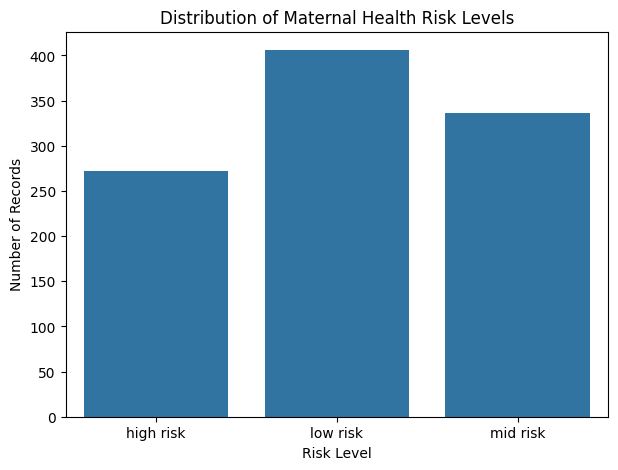

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="RiskLevel")

plt.title("Distribution of Maternal Health Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Records")

plt.show()

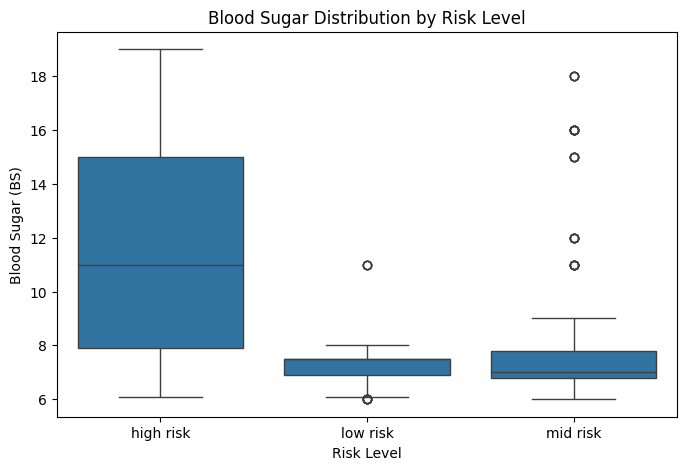

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="RiskLevel", y="BS")

plt.title("Blood Sugar Distribution by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Blood Sugar (BS)")

plt.show()

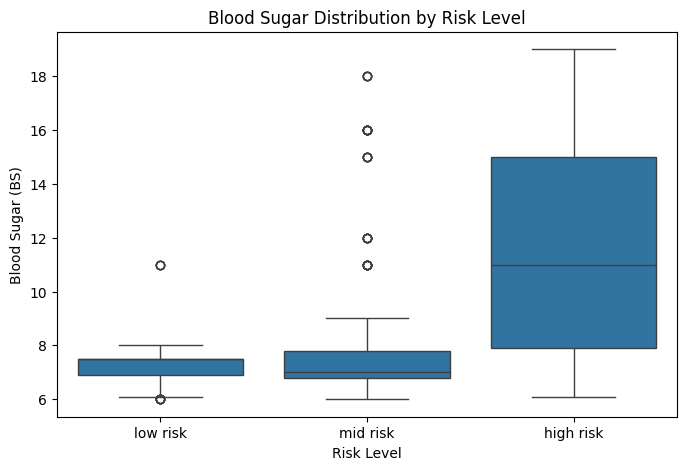

In [17]:
risk_order = ["low risk", "mid risk", "high risk"]

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="RiskLevel",
    y="BS",
    order=risk_order
)

plt.title("Blood Sugar Distribution by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Blood Sugar (BS)")

plt.show()

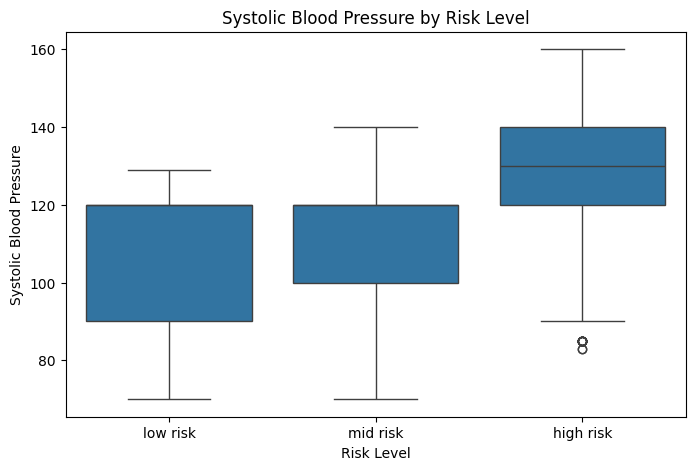

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="RiskLevel",
    y="SystolicBP",
    order=risk_order
)

plt.title("Systolic Blood Pressure by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Systolic Blood Pressure")

plt.show()